### Import the implemented smart contract and compile it with solcx

In [ ]:
# Import necessary libraries
from web3 import Web3
import json
import solcx
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Connect to the local Ethereum network (Ganache)
w3 = Web3(Web3.HTTPProvider("http://127.0.0.1:8545"))

# Check if connection is successful
if not w3.is_connected():
    raise Exception("Failed to connect to the Ethereum network")

# Set the default account (deployer)
w3.eth.default_account = w3.eth.accounts[0]

# Compile the contract using solcx
solcx.install_solc('0.8.0')
solcx.set_solc_version('0.8.0')

# Path to your Solidity contract
contract_path = "./uniform PoR SC.sol"  # Update this path to your contract

# Compile the Solidity contract
with open(contract_path, "r") as file:
    contract_source_code = file.read()

compiled_sol = solcx.compile_standard({
    "language": "Solidity",
    "sources": {
        "ProofOfReputation.sol": {
            "content": contract_source_code
        }
    },
    "settings": {
        "outputSelection": {
            "*": {
                "*": ["abi", "metadata", "evm.bytecode", "evm.sourceMap"]
            }
        }
    }
})

# Extract ABI and bytecode
abi = compiled_sol['contracts']['ProofOfReputation.sol']['ProofOfReputation']['abi']
bytecode = compiled_sol['contracts']['ProofOfReputation.sol']['ProofOfReputation']['evm']['bytecode']['object']

# Deploy the contract
ProofOfReputation = w3.eth.contract(abi=abi, bytecode=bytecode)
tx_hash = ProofOfReputation.constructor().transact()
tx_receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
contract_address = tx_receipt.contractAddress
print(f"Contract deployed at address: {contract_address}")

# Get the deployed contract instance
deployed_contract = w3.eth.contract(address=contract_address, abi=abi)

### run test scripts and plot the results about the reputation scores and selected validators

In [ ]:
import matplotlib.cm as cm
import matplotlib.pyplot as plt

# Attempt to get a colormap
cmap = cm.get_cmap('tab10', 5)

# Define number of clients and rounds
K = 10  # Number of clients
N = 50  # Number of rounds

# Initialize data storage
reputation_history = {address: [] for address in w3.eth.accounts[1:K+1]}  # Adjust for the number of clients
validation_costs = []
selected_validators = []
client_rewards = {address: [0]*N for address in w3.eth.accounts[1:K+1]}   # Initialize with zeros
client_penalties = {address: [0]*N for address in w3.eth.accounts[1:K+1]} # Initialize with zeros

# Function to log gas used
def log_gas_usage(tx_hash, action):
    receipt = w3.eth.get_transaction_receipt(tx_hash)
    # print(f"Gas used for {action}: {receipt.gasUsed}")
    return receipt.gasUsed

# Add a new client with initialized parameters
def add_client(client_address, initial_reputation, historical_performance, trustworthiness, contribution, peer_reviews, validation_accuracy):
    try:
        tx_hash = deployed_contract.functions.addClient(
            client_address,
            initial_reputation,
            historical_performance,
            trustworthiness,
            contribution,
            peer_reviews,
            validation_accuracy
        ).transact()
        log_gas_usage(tx_hash, "Adding client")
    except Exception as e:
        print(f"Error adding client {client_address}: {str(e)}")

# Submit a job
def submit_job(client_address, job_result):
    try:
        tx_hash = deployed_contract.functions.submitJob(job_result).transact({'from': client_address})
        log_gas_usage(tx_hash, f"Job submission by {client_address}")
    except Exception as e:
        print(f"Error submitting job by client {client_address}: {str(e)}")

# Validate all jobs, specifying success or failure for each client
def validate_all_jobs(validator_address, successes):
    try:
        tx_hash = deployed_contract.functions.validateAllJobs(successes).transact({'from': validator_address})
        gas_used = log_gas_usage(tx_hash, "Validating all jobs")
        validation_costs.append(gas_used)
    except Exception as e:
        print(f"Error validating jobs by validator {validator_address}: {str(e)}")

# Fetching updated reputations
def get_reputation(client_address):
    try:
        reputation = deployed_contract.functions.getReputationScore(client_address).call()
        return reputation
    except Exception as e:
        print(f"Error fetching reputation for client {client_address}: {str(e)}")
        return 0

# Event listeners to capture rewards and penalties
def listen_to_events():
    # Create filters for the new events
    client_rewarded_filter = deployed_contract.events.ClientRewarded.create_filter(fromBlock='latest')
    client_penalized_filter = deployed_contract.events.ClientPenalized.create_filter(fromBlock='latest')
    
    return client_rewarded_filter, client_penalized_filter

# Function to process new events
def process_new_events(client_rewarded_filter, client_penalized_filter, current_round):
    # Fetch new events
    new_rewards = client_rewarded_filter.get_new_entries()
    new_penalties = client_penalized_filter.get_new_entries()
    
    # Temporary dictionaries to hold rewards and penalties for this round
    round_rewards = {addr: 0 for addr in client_rewards.keys()}
    round_penalties = {addr: 0 for addr in client_penalties.keys()}
    
    for event in new_rewards:
        client = event['args']['client']
        reward = event['args']['reward']
        round_rewards[client] += reward
        # print(f"Client {client} rewarded with {reward} points.")
    
    for event in new_penalties:
        client = event['args']['client']
        penalty = event['args']['penalty']
        round_penalties[client] += penalty
        # print(f"Client {client} penalized with {penalty} points.")
    
    # Update the client_rewards and client_penalties for the current round
    for client in client_rewards.keys():
        client_rewards[client][current_round] = round_rewards[client]
        client_penalties[client][current_round] = round_penalties[client]

# Run the test with K clients and N rounds
def run_test(K, N):
    # print(f"Running test with {K} clients and {N} rounds\n")
    
    # Add K clients with initialized parameters
    for i in range(1, K + 1):
        # initial_reputation = random.randint(1000, 1500)
        initial_reputation = 1000
        historical_performance = random.randint(0, 10)
        trustworthiness = random.randint(0, 10)
        contribution = random.randint(0, 10)
        peer_reviews = random.randint(0, 10)
        validation_accuracy = random.randint(0, 10)

        add_client(
            w3.eth.accounts[i], 
            initial_reputation,
            historical_performance,
            trustworthiness,
            contribution,
            peer_reviews,
            validation_accuracy
        )
        print(f"Initialized reputation, historical_performance, trustworthiness, contribution, peer_reviews, and validation_accuracy of client {w3.eth.accounts[i]} is {initial_reputation, historical_performance, trustworthiness, contribution, peer_reviews, validation_accuracy}")
        
    # Set up event listeners
    client_rewarded_filter, client_penalized_filter = listen_to_events()
    
    # Run N rounds of job submissions and validations
    for round_num in range(N):
        current_round = round_num  # 0-based index
        # print(f"\n--- Round {round_num + 1} ---")
        
        # Each client submits a job
        for i in range(1, K + 1):
            submit_job(w3.eth.accounts[i], f"Job {round_num + 1} from Client {i}")
        
        # Randomly decide if each job is successful or not
        successes = [random.choice([True, False]) for _ in range(K)]

        # Validator validates all jobs
        current_validator = deployed_contract.functions.getCurrentValidator().call()
        # print(f"Current Validator: {current_validator}")
        validate_all_jobs(current_validator, successes)
        selected_validators.append(current_validator)
        
        # Process any new events (rewards and penalties)
        process_new_events(client_rewarded_filter, client_penalized_filter, current_round)
        
        # Store the updated reputations
        for i in range(1, K + 1):
            reputation = get_reputation(w3.eth.accounts[i])
            reputation_history[w3.eth.accounts[i]].append(reputation)

# Plot the results
def plot_all_results(K, N):
    rounds = list(range(1, N + 1))

    # Reputation per round
    plt.figure(figsize=(12, 6))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', '+','x']
    for i in range(1, K + 1):
        client_addr = w3.eth.accounts[i]
        plt.plot(rounds, reputation_history[client_addr], marker=markers[i % len(markers)], label=f"Client {i} ({client_addr[:K+1]}...)")
    plt.xlabel('Round')
    plt.ylabel('Reputation')
    plt.title('Reputation Per Round')
    plt.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Validation Costs and Selected Validators
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Round')
    ax1.set_ylabel('Gas Used', color=color)
    ax1.plot(rounds, validation_costs, marker='o', color=color, linestyle='-', label='Validation Costs')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx()
    color = 'tab:orange'
    # Map validator addresses to indices or names
    validator_labels = {addr: f"Client {i}" for i, addr in enumerate(w3.eth.accounts[1:K+1], start=1)}
    validator_indices = [validator_labels.get(v, "Unknown") for v in selected_validators]
    ax2.set_ylabel('Selected Validator', color=color)
    ax2.plot(rounds, validator_indices, marker='x', linestyle='-', color=color, label='Selected Validators')
    ax2.tick_params(axis='y', labelcolor=color)

    # Create a legend that combines both
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
    
    plt.title('Validation Costs and Selected Validators Per Round')
    fig.tight_layout()
    plt.show()

    # Cumulative Rewards and Penalties
    plot_cumulative_rewards_penalties(K, N)

# Function to plot cumulative rewards and penalties
def plot_cumulative_rewards_penalties(K, N):
    rounds = list(range(1, N + 1))
    cumulative_rewards = {addr: [] for addr in w3.eth.accounts[1:K+1]}
    cumulative_penalties = {addr: [] for addr in w3.eth.accounts[1:K+1]}
    
    # Initialize cumulative sums
    current_rewards = {addr: 0 for addr in w3.eth.accounts[1:K+1]}
    current_penalties = {addr: 0 for addr in w3.eth.accounts[1:K+1]}
    
    for round_num in range(N):
        for addr in cumulative_rewards.keys():
            if round_num < len(client_rewards[addr]):
                current_rewards[addr] += client_rewards[addr][round_num]
            cumulative_rewards[addr].append(current_rewards[addr])
            
            if round_num < len(client_penalties[addr]):
                current_penalties[addr] += client_penalties[addr][round_num]
            cumulative_penalties[addr].append(current_penalties[addr])
    
# Function to plot all results together
font = {'family': 'serif',
        'weight': 'normal',
        'size': 12}
plt.rc('font', **font)
def plot_all_results(K, N):
    rounds = list(range(1, N + 1))

    # Reputation per round
    plt.figure(figsize=(8, 4))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', '+','x']
    for i in range(1, K + 1):
        client_addr = w3.eth.accounts[i]
        plt.plot(rounds, reputation_history[client_addr], marker=markers[i % len(markers)], label=f"Client {i} ({client_addr[:6]}...)")
    plt.xlabel('Round')
    plt.ylabel('Reputation')
    # plt.title('Reputation Per Round')
    # plt.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
    plt.legend(loc='upper left', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Validation Costs and Selected Validators
    fig, ax1 = plt.subplots(figsize=(8, 4))

    color = 'tab:blue'
    ax1.set_xlabel('Round')
    ax1.set_ylabel('Gas Used', color=color)
    ax1.plot(rounds, validation_costs, marker='o', color=color, linestyle='-', label='Validation Costs')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx()
    color = 'tab:orange'
    # Map validator addresses to indices or names
    validator_labels = {addr: f"Client {i}" for i, addr in enumerate(w3.eth.accounts[1:K+1], start=1)}
    validator_indices = [validator_labels.get(v, "Unknown") for v in selected_validators]
    ax2.set_ylabel('Selected Validator', color=color)
    ax2.plot(rounds, validator_indices, marker='x', linestyle='-', color=color, label='Selected Validators')
    ax2.tick_params(axis='y', labelcolor=color)

    # Create a legend that combines both
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center', fontsize=8, bbox_to_anchor=(1, 1))
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2,loc='upper left',fontsize=8)

    # plt.title('Validation Costs and Selected Validators Per Round')
    fig.tight_layout()
    plt.show()

    

# Example usage
if __name__ == "__main__":
    run_test(K, N)
    plot_all_results(K, N)

    # Cumulative Rewards and Penalties
    plot_cumulative_rewards_penalties(K, N)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# 定义基尼系数计算函数
def gini_coefficient(array):
    """
    计算基尼系数
    """
    array = np.array(array, dtype=np.float64)
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array)  # 处理负值
    array += 0.0000001  # 避免除以零
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

# 转换为DataFrame
rewards_df = pd.DataFrame.from_dict(client_rewards, orient='index')
penalties_df = pd.DataFrame.from_dict(client_penalties, orient='index')

print("Rewards DataFrame:")
print(rewards_df.head())

print("\nPenalties DataFrame:")
print(penalties_df.head())

# 为列命名为Round 1, Round 2, ..., Round N
num_rounds = rewards_df.shape[1]
rewards_df.columns = [f'Round {i+1}' for i in range(num_rounds)]
penalties_df.columns = [f'Round {i+1}' for i in range(num_rounds)]

# 添加客户端地址作为列
rewards_df.reset_index(inplace=True)
rewards_df.rename(columns={'index': 'Client'}, inplace=True)

penalties_df.reset_index(inplace=True)
penalties_df.rename(columns={'index': 'Client'}, inplace=True)

# 合并奖励和惩罚数据
merged_df = rewards_df.merge(penalties_df, on='Client', suffixes=('_Reward', '_Penalty'))

# 计算总奖励和总惩罚
merged_df['Total_Rewards'] = merged_df.filter(like='_Reward').sum(axis=1)
merged_df['Total_Penalties'] = merged_df.filter(like='_Penalty').sum(axis=1)

# 获取最终声誉分数
final_reputations = {client: reps[-1] for client, reps in reputation_history.items()}
merged_df['Final_Reputation'] = merged_df['Client'].map(final_reputations)

# 添加客户端编号和简化名称
merged_df['Client_Number'] = [f'Client {i}' for i in range(1, K + 1)]
merged_df['Client_Display'] = merged_df.apply(
    lambda row: f"Client {int(row['Client_Number'].split()[1])} ({row['Client'][:6]}...)", axis=1
)

# 计算基尼系数
gini_total_rewards = gini_coefficient(merged_df['Total_Rewards'])
gini_total_penalties = gini_coefficient(merged_df['Total_Penalties'])
gini_final_reputation = gini_coefficient(merged_df['Final_Reputation'])

print(f"\nGini Coefficient for Total Rewards: {gini_total_rewards:.4f}")
print(f"Gini Coefficient for Total Penalties: {gini_total_penalties:.4f}")
print(f"Gini Coefficient for Final Reputation: {gini_final_reputation:.4f}")

# 描述性统计
stats = merged_df[['Total_Rewards', 'Total_Penalties', 'Final_Reputation']].describe()
stats.loc['gini_reputation'] = [gini_total_rewards, gini_total_penalties, gini_final_reputation]
print("\nDescriptive Statistics with Gini Coefficient:")
print(stats)

# 设置全局的Seaborn风格
# sns.set(style="whitegrid")

font = {'family': 'serif',
        'weight': 'normal',
        'size': 12}
plt.rc('font', **font)
# 总奖励和总惩罚的柱状图
plt.figure(figsize=(8, 4))
bar_width = 0.35
clients = merged_df['Client_Display']
index = range(len(clients))

# 绘制奖励柱状图
plt.bar(index, merged_df['Total_Rewards'], bar_width, label='Total Rewards', color='green')

# 绘制惩罚柱状图，位置偏移
plt.bar([i + bar_width for i in index], merged_df['Total_Penalties'], bar_width, label='Total Penalties', color='red')

plt.xlabel('Client', fontsize=8)
plt.ylabel('Points', fontsize=8)
plt.title('Total Rewards and Penalties per Client Across Rounds')
plt.xticks([i + bar_width / 2 for i in index], clients, rotation=45, ha='right')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Function to plot validator success rates
def plot_validator_success_rates(validator_total_validations, validator_successful_validations, validator_labels):
    validators = list(validator_total_validations.keys())
    success_rates = []
    validator_names = []

    for validator in validators:
        total = validator_total_validations[validator]
        successes = validator_successful_validations.get(validator, 0)
        success_rate = successes / total if total > 0 else 0
        success_rates.append(success_rate * 100)
        validator_names.append(validator_labels.get(validator, validator[:6]))

    plt.figure(figsize=(8, 4))
    plt.bar(validator_names, success_rates, color='skyblue')
    plt.xlabel('Validator')
    plt.ylabel('Validation Success Rate (%)')
    plt.title('Validation Success Rate per Validator')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
# # 奖励和惩罚的箱线图
# plt.figure(figsize=(14, 8))

# # 奖励的箱线图
# plt.subplot(1, 2, 1)
# sns.boxplot(data=merged_df.filter(like='_Reward'), palette='Greens')
# plt.xlabel('Round', fontsize=12)
# plt.ylabel('Rewards', fontsize=12)
# plt.title('Distribution of Rewards Across Rounds', fontsize=14)
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.yticks(fontsize=10)

# # 惩罚的箱线图
# plt.subplot(1, 2, 2)
# sns.boxplot(data=merged_df.filter(like='_Penalty'), palette='Reds')
# plt.xlabel('Round', fontsize=12)
# plt.ylabel('Penalties', fontsize=12)
# plt.title('Distribution of Penalties Across Rounds', fontsize=14)
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.yticks(fontsize=10)

# plt.tight_layout()
# plt.show()

# 奖励与惩罚的关系散点图
plt.figure(figsize=(8, 4))
sns.scatterplot(
    x='Total_Rewards',
    y='Total_Penalties',
    hue='Client_Display',
    data=merged_df,
    s=100,  # 点的大小
    palette='tab10',  # 使用tab10调色板
    edgecolor='w',  # 点边缘颜色
    alpha=0.7  # 点的透明度
)

plt.xlabel('Total Rewards')
plt.ylabel('Total Penalties')
plt.title('Total Rewards vs Total Penalties per Client')
# plt.legend(title='Client', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=12)
plt.legend(title='Client', loc='upper right', fontsize=8, title_fontsize=10)

plt.grid(True)
plt.tight_layout()
plt.show()

# 奖励与声誉的相关性
correlation = merged_df['Total_Rewards'].corr(merged_df['Final_Reputation'])
print(f"\nCorrelation between Total Rewards and Final Reputation: {correlation:.2f}")

# 回归分析
X = merged_df[['Total_Rewards', 'Total_Penalties']]
y = merged_df['Final_Reputation']
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

# 输出回归结果
print("\nRegression Analysis Summary:")
print(model.summary())

# 相关性热图
plt.figure(figsize=(8, 6))
corr = merged_df[['Total_Rewards', 'Total_Penalties', 'Final_Reputation']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
import plotly.express as px

# 奖励与惩罚的关系散点图（交互式）
fig = px.scatter(
    merged_df,
    x='Total_Rewards',
    y='Total_Penalties',
    color='Client_Display',
    size='Final_Reputation',
    hover_data=['Final_Reputation'],
    title='Total Rewards vs Total Penalties per Client',
    labels={
        'Total_Rewards': 'Total Rewards',
        'Total_Penalties': 'Total Penalties',
        'Client_Display': 'Client'
    }
)

fig.update_layout(
    legend_title_text='Client',
    xaxis_title='Total Rewards',
    yaxis_title='Total Penalties',
    title_font_size=20
)

fig.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define Lorenz Curve function
def lorenz_curve(array):
    """
    Compute Lorenz curve points for a given array.
    """
    array = np.array(array, dtype=np.float64)
    array = np.sort(array)  # Sort the array
    cumulative = np.cumsum(array) / np.sum(array)  # Cumulative sum of array
    cumulative = np.insert(cumulative, 0, 0)  # Add starting point (0,0)
    return cumulative

# Sample test data (replace this with your actual data)
# Assuming 'merged_df' already contains 'Total_Rewards', 'Total_Penalties', and 'Final_Reputation'

# Calculate Lorenz curve points for Total Rewards, Total Penalties, and Final Reputation
lorenz_rewards = lorenz_curve(merged_df['Total_Rewards'])
lorenz_penalties = lorenz_curve(merged_df['Total_Penalties'])
lorenz_reputation = lorenz_curve(merged_df['Final_Reputation'])

# Create Lorenz Curve plots
plt.figure(figsize=(10, 6))

# Plot Lorenz Curve for Total Rewards
x = np.linspace(0., 1., len(lorenz_rewards))  # Create equally spaced values for x-axis
plt.plot(x, lorenz_rewards, label='Total Rewards', color='green')

# Plot Lorenz Curve for Total Penalties
plt.plot(x, lorenz_penalties, label='Total Penalties', color='red')

# Plot Lorenz Curve for Final Reputation
plt.plot(x, lorenz_reputation, label='Final Reputation', color='blue')

# Plot the equality line (y=x), representing perfect equality
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Equality Line')

# Customize the plot
plt.xlabel('Cumulative Share of Clients', fontsize=14)
plt.ylabel('Cumulative Share of Points', fontsize=14)
plt.title('Lorenz Curve for Rewards, Penalties, and Reputation', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 计算相关系数矩阵
corr_matrix = merged_df[['Total_Rewards', 'Total_Penalties', 'Final_Reputation']].corr()
print(corr_matrix)


### Updated!!

Contract deployed at address: 0x7Fa2B6fAE1C2a44EE9001abD76b5b3D29C34365A

Overall Validation Success Rate: 50.60%

Validation Success Rate for Each Validator:
Client 1: 35.00% (7/20 successful validations)
Client 10: 50.65% (233/460 successful validations)
Client 6: 65.00% (13/20 successful validations)


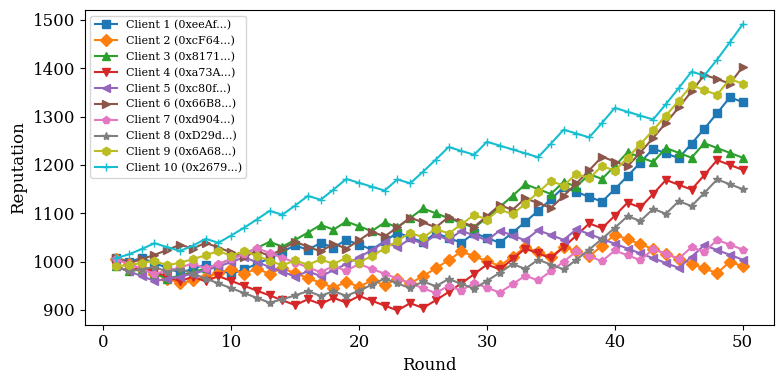

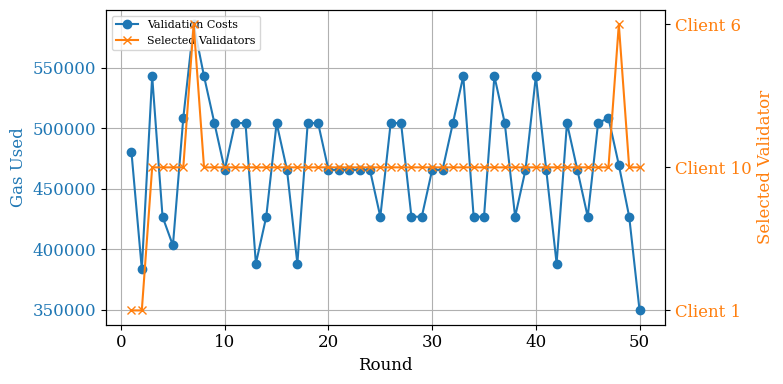

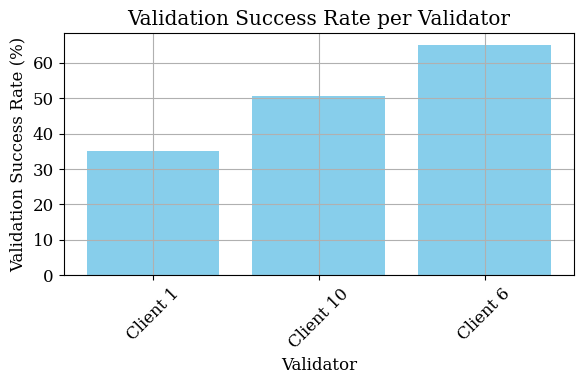

In [60]:
# Import necessary libraries
from web3 import Web3
import json
import solcx
import random
import matplotlib.pyplot as plt
from collections import defaultdict

# Connect to the local Ethereum network (Ganache)
w3 = Web3(Web3.HTTPProvider("http://127.0.0.1:8545"))

# Check if connection is successful
if not w3.is_connected():
    raise Exception("Failed to connect to the Ethereum network")

# Set the default account (deployer)
w3.eth.default_account = w3.eth.accounts[0]

# Compile the contract using solcx
solcx.install_solc('0.8.0')
solcx.set_solc_version('0.8.0')

# Path to your Solidity contract
contract_path = "./uniform PoR SC.sol"  # Update this path to your contract

# Compile the Solidity contract
with open(contract_path, "r") as file:
    contract_source_code = file.read()

compiled_sol = solcx.compile_standard({
    "language": "Solidity",
    "sources": {
        "ProofOfReputation.sol": {
            "content": contract_source_code
        }
    },
    "settings": {
        "outputSelection": {
            "*": {
                "*": ["abi", "metadata", "evm.bytecode", "evm.sourceMap"]
            }
        }
    }
})

# Extract ABI and bytecode
abi = compiled_sol['contracts']['ProofOfReputation.sol']['ProofOfReputation']['abi']
bytecode = compiled_sol['contracts']['ProofOfReputation.sol']['ProofOfReputation']['evm']['bytecode']['object']

# Deploy the contract
ProofOfReputation = w3.eth.contract(abi=abi, bytecode=bytecode)
tx_hash = ProofOfReputation.constructor().transact()
tx_receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
contract_address = tx_receipt.contractAddress
print(f"Contract deployed at address: {contract_address}")

# Get the deployed contract instance
deployed_contract = w3.eth.contract(address=contract_address, abi=abi)
# Define number of clients and rounds
K = 10  # Number of clients
N = 50  # Number of rounds

# Initialize data storage
reputation_history = {address: [] for address in w3.eth.accounts[1:K+1]}  # Adjust for the number of clients
validation_costs = []
selected_validators = []
client_rewards = {address: [0]*N for address in w3.eth.accounts[1:K+1]}   # Initialize with zeros
client_penalties = {address: [0]*N for address in w3.eth.accounts[1:K+1]} # Initialize with zeros

# Function to log gas used
def log_gas_usage(tx_hash, action):
    receipt = w3.eth.wait_for_transaction_receipt(tx_hash)
    return receipt['gasUsed']

# Add a new client with initialized parameters
def add_client(client_address, initial_reputation, historical_performance, trustworthiness, contribution, peer_reviews, validation_accuracy):
    try:
        tx_hash = deployed_contract.functions.addClient(
            client_address,
            initial_reputation,
            historical_performance,
            trustworthiness,
            contribution,
            peer_reviews,
            validation_accuracy
        ).transact({'from': w3.eth.accounts[0]})
        log_gas_usage(tx_hash, "Adding client")
    except Exception as e:
        print(f"Error adding client {client_address}: {str(e)}")

# Submit a job
def submit_job(client_address, job_result):
    try:
        tx_hash = deployed_contract.functions.submitJob(job_result).transact({'from': client_address})
        log_gas_usage(tx_hash, f"Job submission by {client_address}")
    except Exception as e:
        print(f"Error submitting job by client {client_address}: {str(e)}")

# Validate all jobs, specifying success or failure for each client
def validate_all_jobs(validator_address, successes):
    try:
        tx_hash = deployed_contract.functions.validateAllJobs(successes).transact({'from': validator_address})
        gas_used = log_gas_usage(tx_hash, "Validating all jobs")
        validation_costs.append(gas_used)
    except Exception as e:
        print(f"Error validating jobs by validator {validator_address}: {str(e)}")

# Fetching updated reputations
def get_reputation(client_address):
    try:
        reputation = deployed_contract.functions.getReputationScore(client_address).call()
        return reputation
    except Exception as e:
        print(f"Error fetching reputation for client {client_address}: {str(e)}")
        return 0

# Event listeners to capture rewards and penalties
def listen_to_events():
    # Create filters for the new events
    client_rewarded_filter = deployed_contract.events.ClientRewarded.create_filter(fromBlock='latest')
    client_penalized_filter = deployed_contract.events.ClientPenalized.create_filter(fromBlock='latest')
    
    return client_rewarded_filter, client_penalized_filter

# Function to process new events
def process_new_events(client_rewarded_filter, client_penalized_filter, current_round):
    # Fetch new events
    new_rewards = client_rewarded_filter.get_new_entries()
    new_penalties = client_penalized_filter.get_new_entries()
    
    # Temporary dictionaries to hold rewards and penalties for this round
    round_rewards = {addr: 0 for addr in client_rewards.keys()}
    round_penalties = {addr: 0 for addr in client_penalties.keys()}
    
    for event in new_rewards:
        client = event['args']['client']
        reward = event['args']['reward']
        round_rewards[client] += reward
        
    for event in new_penalties:
        client = event['args']['client']
        penalty = event['args']['penalty']
        round_penalties[client] += penalty
        
    # Update the client_rewards and client_penalties for the current round
    for client in client_rewards.keys():
        client_rewards[client][current_round] = round_rewards[client]
        client_penalties[client][current_round] = round_penalties[client]

# Run the test with K clients and N rounds
def run_test(K, N):
    # print(f"Running test with {K} clients and {N} rounds\n")
    
    # Initialize counters for validation success rate
    total_validations = 0
    total_successes = 0
    per_round_success_rates = []
    
    # Initialize validator statistics
    validator_total_validations = {}
    validator_successful_validations = {}
    
    # Map validator addresses to indices or names
    validator_labels = {addr: f"Client {i}" for i, addr in enumerate(w3.eth.accounts[1:K+1], start=1)}
    
    # Add K clients with initialized parameters
    for i in range(1, K + 1):
        initial_reputation = 1000
        historical_performance = random.randint(0, 10)
        trustworthiness = random.randint(0, 10)
        contribution = random.randint(0, 10)
        peer_reviews = random.randint(0, 10)
        validation_accuracy = random.randint(0, 10)

        add_client(
            w3.eth.accounts[i], 
            initial_reputation,
            historical_performance,
            trustworthiness,
            contribution,
            peer_reviews,
            validation_accuracy
        )
        # print(f"Initialized parameters of client {w3.eth.accounts[i]}: {initial_reputation, historical_performance, trustworthiness, contribution, peer_reviews, validation_accuracy}")
        
    # Set up event listeners
    client_rewarded_filter, client_penalized_filter = listen_to_events()
    
    # Run N rounds of job submissions and validations
    for round_num in range(N):
        current_round = round_num  # 0-based index
        
        # Each client submits a job
        for i in range(1, K + 1):
            submit_job(w3.eth.accounts[i], f"Job {round_num + 1} from Client {i}")
        
        # Randomly decide if each job is successful or not
        successes = [random.choice([True, False]) for _ in range(K)]
        
        # Update validation counters
        total_validations += K  # Each client has one job validated per round
        total_successes += sum(successes)  # Count the number of True values in successes
        
        # Calculate per-round success rate
        round_success_rate = sum(successes) / K
        per_round_success_rates.append(round_success_rate)
        
        # Validator validates all jobs
        current_validator = deployed_contract.functions.getCurrentValidator().call()
        # print(f"Round {round_num + 1} - Current Validator: {current_validator}")
        selected_validators.append(current_validator)
        
        # Initialize validator counts if not already done
        if current_validator not in validator_total_validations:
            validator_total_validations[current_validator] = 0
            validator_successful_validations[current_validator] = 0

        # Update validator's total validations
        validator_total_validations[current_validator] += K  # Validator validates all K jobs

        # Update validator's successful validations
        validator_successful_validations[current_validator] += sum(successes)  # Count of successful validations

        # Validator validates all jobs
        validate_all_jobs(current_validator, successes)
        
        # Process any new events (rewards and penalties)
        process_new_events(client_rewarded_filter, client_penalized_filter, current_round)
        
        # Store the updated reputations
        for i in range(1, K + 1):
            reputation = get_reputation(w3.eth.accounts[i])
            reputation_history[w3.eth.accounts[i]].append(reputation)
    
    # Calculate overall validation success rate
    validation_success_rate = total_successes / total_validations if total_validations > 0 else 0
    print(f"\nOverall Validation Success Rate: {validation_success_rate * 100:.2f}%")
    
    # Calculate and display the validation success rate for each validator
    print("\nValidation Success Rate for Each Validator:")
    for validator, total in validator_total_validations.items():
        successes = validator_successful_validations.get(validator, 0)
        success_rate = successes / total if total > 0 else 0
        validator_name = validator_labels.get(validator, validator[:6])  # Get a readable name
        print(f"{validator_name}: {success_rate * 100:.2f}% ({successes}/{total} successful validations)")
    
    # Return the success rates and validator stats
    return (validation_success_rate,
            per_round_success_rates,
            validator_total_validations,
            validator_successful_validations,
            validator_labels)

# Plot the validation success rate per round
def plot_validation_success_rate(per_round_success_rates):
    rounds = list(range(1, len(per_round_success_rates) + 1))
    plt.figure(figsize=(8, 4))
    plt.plot(rounds, [rate * 100 for rate in per_round_success_rates], marker='o', linestyle='-')
    plt.xlabel('Round')
    plt.ylabel('Validation Success Rate (%)')
    plt.title('Validation Success Rate Per Round')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Function to plot validator success rates
def plot_validator_success_rates(validator_total_validations, validator_successful_validations, validator_labels):
    validators = list(validator_total_validations.keys())
    success_rates = []
    validator_names = []

    for validator in validators:
        total = validator_total_validations[validator]
        successes = validator_successful_validations.get(validator, 0)
        success_rate = successes / total if total > 0 else 0
        success_rates.append(success_rate * 100)
        validator_names.append(validator_labels.get(validator, validator[:6]))

    plt.figure(figsize=(6, 4))
    plt.bar(validator_names, success_rates, color='skyblue')
    plt.xlabel('Validator')
    plt.ylabel('Validation Success Rate (%)')
    plt.title('Validation Success Rate per Validator')
    plt.xticks(rotation=45)
    plt.grid()
    plt.tight_layout()
    plt.show()

# Function to plot cumulative rewards and penalties
def plot_cumulative_rewards_penalties(K, N):
    rounds = list(range(1, N + 1))
    cumulative_rewards = {addr: [] for addr in w3.eth.accounts[1:K+1]}
    cumulative_penalties = {addr: [] for addr in w3.eth.accounts[1:K+1]}
    
    # Initialize cumulative sums
    current_rewards = {addr: 0 for addr in w3.eth.accounts[1:K+1]}
    current_penalties = {addr: 0 for addr in w3.eth.accounts[1:K+1]}
    
    for round_num in range(N):
        for addr in cumulative_rewards.keys():
            if round_num < len(client_rewards[addr]):
                current_rewards[addr] += client_rewards[addr][round_num]
            cumulative_rewards[addr].append(current_rewards[addr])
            
            if round_num < len(client_penalties[addr]):
                current_penalties[addr] += client_penalties[addr][round_num]
            cumulative_penalties[addr].append(current_penalties[addr])
    
    # Plot cumulative rewards and penalties
    plt.figure(figsize=(8, 4))
    for i in range(1, K + 1):
        client_addr = w3.eth.accounts[i]
        plt.plot(rounds, cumulative_rewards[client_addr], label=f"Client {i} Rewards")
        plt.plot(rounds, cumulative_penalties[client_addr], label=f"Client {i} Penalties", linestyle='--')
    plt.xlabel('Round')
    plt.ylabel('Cumulative Rewards/Penalties')
    plt.title('Cumulative Rewards and Penalties Per Client')
    plt.legend(loc='upper left', fontsize=8)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Plot the results
def plot_all_results(K, N):
    rounds = list(range(1, N + 1))

    # Reputation per round
    plt.figure(figsize=(12, 6))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', '+','x']
    for i in range(1, K + 1):
        client_addr = w3.eth.accounts[i]
        plt.plot(rounds, reputation_history[client_addr], marker=markers[i % len(markers)], color='black', label=f"Client {i} ({client_addr[:K+1]}...)")
    plt.xlabel('Round')
    plt.ylabel('Reputation')
    plt.title('Reputation Per Round')
    plt.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
    # plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Validation Costs and Selected Validators
    fig, ax1 = plt.subplots(figsize=(12, 6))

    color = 'tab:blue'
    ax1.set_xlabel('Round')
    ax1.set_ylabel('Gas Used', color=color)
    ax1.plot(rounds, validation_costs, marker='o', color=color, linestyle='-', label='Validation Costs')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx()
    color = 'tab:orange'
    # Map validator addresses to indices or names
    validator_labels = {addr: f"Client {i}" for i, addr in enumerate(w3.eth.accounts[1:K+1], start=1)}
    validator_indices = [validator_labels.get(v, "Unknown") for v in selected_validators]
    ax2.set_ylabel('Selected Validator', color=color)
    ax2.plot(rounds, validator_indices, marker='x', linestyle='-', color=color, label='Selected Validators')
    ax2.tick_params(axis='y', labelcolor=color)

    # Create a legend that combines both
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
    
    plt.title('Validation Costs and Selected Validators Per Round')
    fig.tight_layout()
    plt.show()

    # Cumulative Rewards and Penalties
    plot_cumulative_rewards_penalties(K, N)

# Function to plot cumulative rewards and penalties
def plot_cumulative_rewards_penalties(K, N):
    rounds = list(range(1, N + 1))
    cumulative_rewards = {addr: [] for addr in w3.eth.accounts[1:K+1]}
    cumulative_penalties = {addr: [] for addr in w3.eth.accounts[1:K+1]}
    
    # Initialize cumulative sums
    current_rewards = {addr: 0 for addr in w3.eth.accounts[1:K+1]}
    current_penalties = {addr: 0 for addr in w3.eth.accounts[1:K+1]}
    
    for round_num in range(N):
        for addr in cumulative_rewards.keys():
            if round_num < len(client_rewards[addr]):
                current_rewards[addr] += client_rewards[addr][round_num]
            cumulative_rewards[addr].append(current_rewards[addr])
            
            if round_num < len(client_penalties[addr]):
                current_penalties[addr] += client_penalties[addr][round_num]
            cumulative_penalties[addr].append(current_penalties[addr])
    
# Function to plot all results together
font = {'family': 'serif',
        'weight': 'normal',
        'size': 12}
plt.rc('font', **font)
def plot_all_results(K, N):
    rounds = list(range(1, N + 1))

    # Reputation per round
    plt.figure(figsize=(8, 4))
    markers = ['o', 's', 'D', '^', 'v', '<', '>', 'p', '*', 'h', '+','x']
    # colors=['#EAC0BD', '#F17060', '#DA3E2F','#C11317','#A20922', '#F0C294', '#FE9549', '#F4711F', '#DE4D05', '#A53302']
    for i in range(1, K + 1):
        client_addr = w3.eth.accounts[i]
        # plt.plot(rounds, reputation_history[client_addr], marker=markers[i % len(markers)],color = colors[i % len(colors)],label=f"Client {i} ({client_addr[:K+1]}...)")
        plt.plot(rounds, reputation_history[client_addr], marker=markers[i % len(markers)],label=f"Client {i} ({client_addr[:6]}...)")
    plt.xlabel('Round')
    plt.ylabel('Reputation')
    # plt.title('Reputation Per Round')
    # plt.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1, 1))
    plt.legend(loc='upper left', fontsize=8)
    # plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Validation Costs and Selected Validators
    fig, ax1 = plt.subplots(figsize=(8, 4))

    color = 'tab:blue'
    ax1.set_xlabel('Round')
    ax1.set_ylabel('Gas Used', color=color)
    ax1.plot(rounds, validation_costs, marker='o', color=color, linestyle='-', label='Validation Costs')
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.grid(True)

    ax2 = ax1.twinx()
    color = 'tab:orange'
    # Map validator addresses to indices or names
    validator_labels = {addr: f"Client {i}" for i, addr in enumerate(w3.eth.accounts[1:K+1], start=1)}
    validator_indices = [validator_labels.get(v, "Unknown") for v in selected_validators]
    ax2.set_ylabel('Selected Validator', color=color)
    ax2.plot(rounds, validator_indices, marker='x', linestyle='-', color=color, label='Selected Validators')
    ax2.tick_params(axis='y', labelcolor=color)

    # Create a legend that combines both
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    # ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center', fontsize=8, bbox_to_anchor=(1, 1))
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2,loc='upper left',fontsize=8)

    # plt.title('Validation Costs and Selected Validators Per Round')
    fig.tight_layout()
    plt.show()


# Example usage
if __name__ == "__main__":
    # Set a random seed for reproducibility (optional)
    random.seed(1000)

    # Run the test
    (validation_success_rate,
     per_round_success_rates,
     validator_total_validations,
     validator_successful_validations,
     validator_labels) = run_test(K, N)
    
    # Plot results
    plot_all_results(K, N)
    plot_cumulative_rewards_penalties(K, N)
    # plot_validation_success_rate(per_round_success_rates)
    plot_validator_success_rates(validator_total_validations, validator_successful_validations, validator_labels)


Rewards DataFrame:
                                            0   1   2   3   4   5   6   7   \
0xeeAfCc13f39Df4E056aAf5F8dAF6e430333BE739   6   0   7   0   0   0   8   9   
0xcF642dC28AEaC53f2EDa3d6A28D9836f0D8C0042   5   0   0   0   0   0   6   7   
0x8171fe3ae82477f74984CCaef203999f64922d67   0   0   5   0   0   6   7   8   
0xa73A4B4f26754f8730Cf3c6F17B6567752D453B8   0   0   9   0   0   0  10   0   
0xc80faaF5a057e300Fbd7A913095AAEFe8cebAa36   0   0   0   0   4   5   6   7   

                                            8   9   ...  40  41  42  43  44  \
0xeeAfCc13f39Df4E056aAf5F8dAF6e430333BE739   0   0  ...  27  28  29   0   0   
0xcF642dC28AEaC53f2EDa3d6A28D9836f0D8C0042   8   9  ...   0   0   0   0   0   
0x8171fe3ae82477f74984CCaef203999f64922d67   9  10  ...  28   0   0  29   0   
0xa73A4B4f26754f8730Cf3c6F17B6567752D453B8  11   0  ...  27   0  28  29   0   
0xc80faaF5a057e300Fbd7A913095AAEFe8cebAa36   8   9  ...   0   0   0   0   0   

                                     

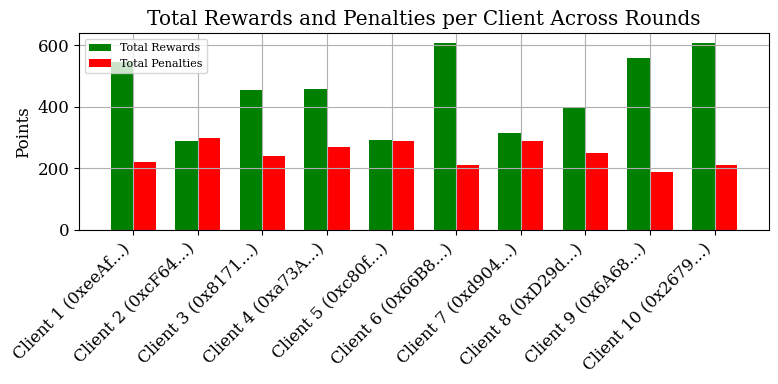


Correlation between Total Rewards and Final Reputation: 0.989

Correlation between Total Penalties and Final Reputation: -0.941


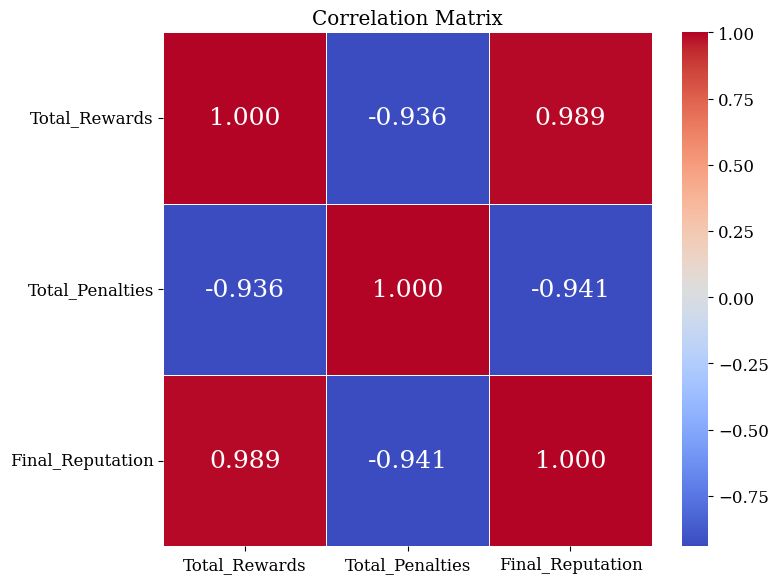

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np

# 定义基尼系数计算函数
def gini_coefficient(array):
    """
    计算基尼系数
    """
    array = np.array(array, dtype=np.float64)
    array = array.flatten()
    if np.amin(array) < 0:
        array -= np.amin(array)  # 处理负值
    array += 0.0000001  # 避免除以零
    array = np.sort(array)
    index = np.arange(1, array.shape[0] + 1)
    n = array.shape[0]
    return ((np.sum((2 * index - n - 1) * array)) / (n * np.sum(array)))

# 转换为DataFrame
rewards_df = pd.DataFrame.from_dict(client_rewards, orient='index')
penalties_df = pd.DataFrame.from_dict(client_penalties, orient='index')

print("Rewards DataFrame:")
print(rewards_df.head())

print("\nPenalties DataFrame:")
print(penalties_df.head())

# 为列命名为Round 1, Round 2, ..., Round N
num_rounds = rewards_df.shape[1]
rewards_df.columns = [f'Round {i+1}' for i in range(num_rounds)]
penalties_df.columns = [f'Round {i+1}' for i in range(num_rounds)]

# 添加客户端地址作为列
rewards_df.reset_index(inplace=True)
rewards_df.rename(columns={'index': 'Client'}, inplace=True)

penalties_df.reset_index(inplace=True)
penalties_df.rename(columns={'index': 'Client'}, inplace=True)

# 合并奖励和惩罚数据
merged_df = rewards_df.merge(penalties_df, on='Client', suffixes=('_Reward', '_Penalty'))

# 计算总奖励和总惩罚
merged_df['Total_Rewards'] = merged_df.filter(like='_Reward').sum(axis=1)
merged_df['Total_Penalties'] = merged_df.filter(like='_Penalty').sum(axis=1)

# 获取最终声誉分数
final_reputations = {client: reps[-1] for client, reps in reputation_history.items()}
merged_df['Final_Reputation'] = merged_df['Client'].map(final_reputations)

# 添加客户端编号和简化名称
merged_df['Client_Number'] = [f'Client {i}' for i in range(1, K + 1)]
merged_df['Client_Display'] = merged_df.apply(
    lambda row: f"Client {int(row['Client_Number'].split()[1])} ({row['Client'][:6]}...)", axis=1
)

# 计算基尼系数
gini_total_rewards = gini_coefficient(merged_df['Total_Rewards'])
gini_total_penalties = gini_coefficient(merged_df['Total_Penalties'])
gini_final_reputation = gini_coefficient(merged_df['Final_Reputation'])

print(f"\nGini Coefficient for Total Rewards: {gini_total_rewards:.4f}")
print(f"Gini Coefficient for Total Penalties: {gini_total_penalties:.4f}")
print(f"Gini Coefficient for Final Reputation: {gini_final_reputation:.4f}")

# 描述性统计
stats = merged_df[['Total_Rewards', 'Total_Penalties', 'Final_Reputation']].describe()
stats.loc['gini_reputation'] = [gini_total_rewards, gini_total_penalties, gini_final_reputation]
print("\nDescriptive Statistics with Gini Coefficient:")
print(stats)

# 设置全局的Seaborn风格
# sns.set(style="whitegrid")

font = {'family': 'serif',
        'weight': 'normal',
        'size': 12}
plt.rc('font', **font)
# 总奖励和总惩罚的柱状图
plt.figure(figsize=(8, 4))
bar_width = 0.35
clients = merged_df['Client_Display']
index = range(len(clients))

# 绘制奖励柱状图
plt.bar(index, merged_df['Total_Rewards'], bar_width, label='Total Rewards', color='green')

# 绘制惩罚柱状图，位置偏移
plt.bar([i + bar_width for i in index], merged_df['Total_Penalties'], bar_width, label='Total Penalties', color='red')

# plt.xlabel('Client')
plt.ylabel('Points')
plt.title('Total Rewards and Penalties per Client Across Rounds')
plt.xticks([i + bar_width / 2 for i in index], clients, rotation=45, ha='right')
plt.legend(fontsize=8)
plt.tight_layout()
plt.grid()
plt.show()

# Function to plot validator success rates
def plot_validator_success_rates(validator_total_validations, validator_successful_validations, validator_labels):
    validators = list(validator_total_validations.keys())
    success_rates = []
    validator_names = []

    for validator in validators:
        total = validator_total_validations[validator]
        successes = validator_successful_validations.get(validator, 0)
        success_rate = successes / total if total > 0 else 0
        success_rates.append(success_rate * 100)
        validator_names.append(validator_labels.get(validator, validator[:6]))

    plt.figure(figsize=(8, 4))
    plt.bar(validator_names, success_rates, color='skyblue')
    plt.xlabel('Validator')
    plt.ylabel('Validation Success Rate (%)')
    plt.title('Validation Success Rate per Validator')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
# # 奖励和惩罚的箱线图
# plt.figure(figsize=(14, 8))

# # 奖励的箱线图
# plt.subplot(1, 2, 1)
# sns.boxplot(data=merged_df.filter(like='_Reward'), palette='Greens')
# plt.xlabel('Round', fontsize=12)
# plt.ylabel('Rewards', fontsize=12)
# plt.title('Distribution of Rewards Across Rounds', fontsize=14)
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.yticks(fontsize=10)

# # 惩罚的箱线图
# plt.subplot(1, 2, 2)
# sns.boxplot(data=merged_df.filter(like='_Penalty'), palette='Reds')
# plt.xlabel('Round', fontsize=12)
# plt.ylabel('Penalties', fontsize=12)
# plt.title('Distribution of Penalties Across Rounds', fontsize=14)
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.yticks(fontsize=10)

# plt.tight_layout()
# plt.show()

# 奖励与惩罚的关系散点图
# plt.figure(figsize=(4, 4))
# sns.scatterplot(
#     x='Total_Rewards',
#     y='Total_Penalties',
#     hue='Client_Display',
#     data=merged_df,
#     s=100,  # 点的大小
#     palette='tab10',  # 使用tab10调色板
#     edgecolor='w',  # 点边缘颜色
#     alpha=0.8  # 点的透明度
# )

# plt.xlabel('Total Rewards')
# plt.ylabel('Total Penalties')
# # plt.title('Total Rewards vs Total Penalties per Client')
# # plt.legend(title='Client', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, title_fontsize=12)
# # plt.legend(title='Client', fontsize=8, title_fontsize=10)
# plt.legend(title='Client', loc='upper right', fontsize=8, title_fontsize=10)


# plt.grid(True)
# plt.tight_layout()
# plt.show()

# 奖励与声誉的相关性
correlation1 = merged_df['Total_Rewards'].corr(merged_df['Final_Reputation'])
correlation2 = merged_df['Total_Penalties'].corr(merged_df['Final_Reputation'])

print(f"\nCorrelation between Total Rewards and Final Reputation: {correlation1:.3f}")
print(f"\nCorrelation between Total Penalties and Final Reputation: {correlation2:.3f}")

# # 回归分析
# X = merged_df[['Total_Rewards', 'Total_Penalties']]
# y = merged_df['Final_Reputation']
# X = sm.add_constant(X)
# model = sm.OLS(y, X).fit()

# # 输出回归结果
# print("\nRegression Analysis Summary:")
# print(model.summary())

# 相关性热图
plt.figure(figsize=(8, 6))
corr = merged_df[['Total_Rewards', 'Total_Penalties', 'Final_Reputation']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".3f", linewidths=0.5, annot_kws={"size": 18})
plt.title('Correlation Matrix')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()


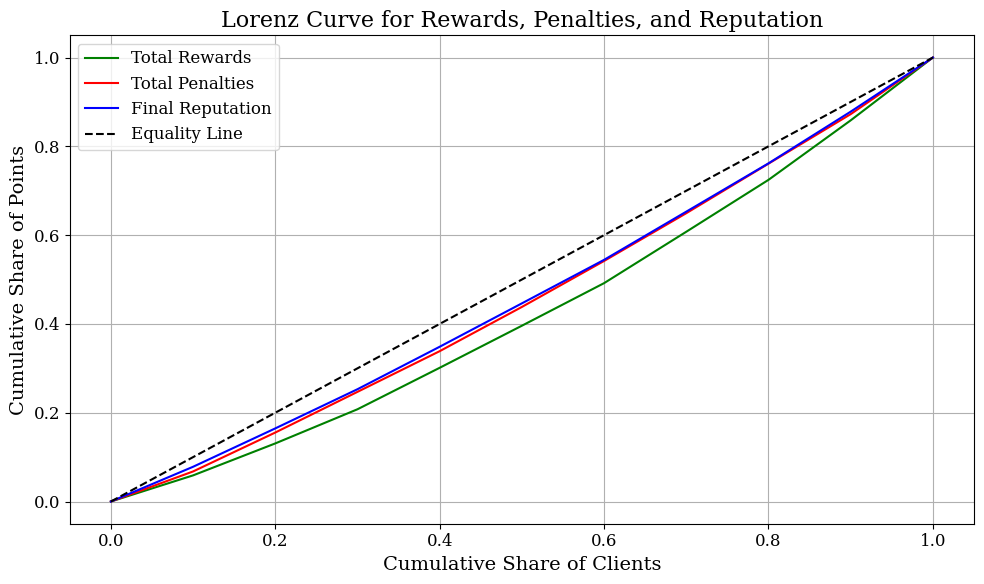

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define Lorenz Curve function
def lorenz_curve(array):
    """
    Compute Lorenz curve points for a given array.
    """
    array = np.array(array, dtype=np.float64)
    array = np.sort(array)  # Sort the array
    cumulative = np.cumsum(array) / np.sum(array)  # Cumulative sum of array
    cumulative = np.insert(cumulative, 0, 0)  # Add starting point (0,0)
    return cumulative

# Sample test data (replace this with your actual data)
# Assuming 'merged_df' already contains 'Total_Rewards', 'Total_Penalties', and 'Final_Reputation'

# Calculate Lorenz curve points for Total Rewards, Total Penalties, and Final Reputation
lorenz_rewards = lorenz_curve(merged_df['Total_Rewards'])
lorenz_penalties = lorenz_curve(merged_df['Total_Penalties'])
lorenz_reputation = lorenz_curve(merged_df['Final_Reputation'])

# Create Lorenz Curve plots
plt.figure(figsize=(10, 6))

# Plot Lorenz Curve for Total Rewards
x = np.linspace(0., 1., len(lorenz_rewards))  # Create equally spaced values for x-axis
plt.plot(x, lorenz_rewards, label='Total Rewards', color='green')

# Plot Lorenz Curve for Total Penalties
plt.plot(x, lorenz_penalties, label='Total Penalties', color='red')

# Plot Lorenz Curve for Final Reputation
plt.plot(x, lorenz_reputation, label='Final Reputation', color='blue')

# Plot the equality line (y=x), representing perfect equality
plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Equality Line')

# Customize the plot
plt.xlabel('Cumulative Share of Clients', fontsize=14)
plt.ylabel('Cumulative Share of Points', fontsize=14)
plt.title('Lorenz Curve for Rewards, Penalties, and Reputation', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()